In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [5]:
# Transform: convert to tensor and normalize to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

# CIFAR-10 dataset
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)


100%|██████████| 170M/170M [00:04<00:00, 36.4MB/s] 


In [6]:
class EncoderDecoderCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),   # 32x32 → 16x16
            nn.ReLU(),

            nn.Conv2d(64, 128, 4, 2, 1), # 16x16 → 8x8
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 8x8 → 16x16
            nn.ReLU(),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),    # 16x16 → 32x32
            nn.Tanh()  # Output in [-1, 1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EncoderDecoderCNN().to(device)

# L1 loss (can use nn.MSELoss())
criterion = nn.L1Loss()

optimizer = optim.Adam(model.parameters(), lr=0.0002)


In [8]:
epochs = 10

for epoch in range(epochs):
    running_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, images)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")


Epoch [1/10], Loss: 0.0855
Epoch [2/10], Loss: 0.0451
Epoch [3/10], Loss: 0.0373
Epoch [4/10], Loss: 0.0330
Epoch [5/10], Loss: 0.0300
Epoch [6/10], Loss: 0.0278
Epoch [7/10], Loss: 0.0260
Epoch [8/10], Loss: 0.0246
Epoch [9/10], Loss: 0.0234
Epoch [10/10], Loss: 0.0224


In [9]:
def show_images(original, reconstructed):
    original = original.cpu() * 0.5 + 0.5
    reconstructed = reconstructed.cpu() * 0.5 + 0.5

    fig, axs = plt.subplots(2, 6, figsize=(12, 4))

    for i in range(6):
        axs[0, i].imshow(original[i].permute(1, 2, 0))
        axs[0, i].axis('off')
        axs[1, i].imshow(reconstructed[i].permute(1, 2, 0))
        axs[1, i].axis('off')

    axs[0, 0].set_ylabel("Original")
    axs[1, 0].set_ylabel("Output")
    plt.show()


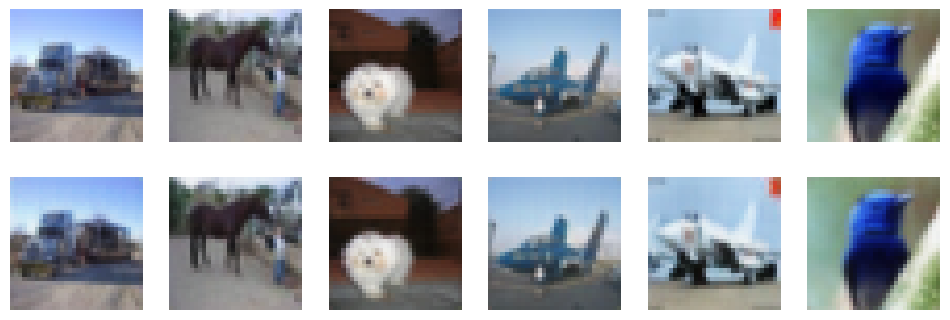

In [10]:
# Get sample images
images, _ = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)

show_images(images, outputs)
